In [1]:
import os

os.environ["KAGGLE_USERNAME"] = "redacted"
os.environ["KAGGLE_KEY"] = "export redacted"

In [2]:
# ===== CONFIGURATION =====
NUM_SAMPLES = 50          # <<< CHANGE THIS TO CONTROL SAMPLE SIZE
MAX_LEN = 512
RANDOM_SEED = 42

import random
import numpy as np
import torch

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [3]:
import os, zipfile, pandas as pd

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

with zipfile.ZipFile("fake-and-real-news-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real]).sample(frac=1, random_state=42)
df["text"] = df["title"] + " " + df["text"]
df = df[["text", "label"]]


Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 1.74GB/s]


In [4]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, _, _ = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [6]:
def truncate_text(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    return tokenizer.decode(enc["input_ids"][0], skip_special_tokens=True)

truncated_test_texts = [
    truncate_text(t) for t in test_texts[:NUM_SAMPLES]
]

print(f"Using {len(truncated_test_texts)} truncated samples")


Using 50 truncated samples


In [7]:
def predict_label_and_prob(text):
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN,
                    return_tensors="pt").to(device)
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=-1)[0]
    label = probs.argmax().item()
    return label, probs[label].item()


In [11]:
import shap

def shap_model(texts):
    if isinstance(texts, str):
        texts = [texts]
    # Ensure texts is a list of strings for the tokenizer
    texts = [str(t) for t in texts]
    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits

    return logits.cpu().numpy()

explainer = shap.Explainer(shap_model, shap.maskers.Text(tokenizer))
shap_values = explainer(truncated_test_texts)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 1/50 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   6%|▌         | 3/50 [00:35<06:12,  7.92s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

PartitionExplainer explainer:  98%|█████████▊| 49/50 [09:52<00:14, 14.56s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 50/50 [10:09<00:00, 15.09s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 51it [10:16, 12.32s/it]


In [12]:
def tokens_to_words(tokens, values):
    words, scores = [], []
    cur_w, cur_s = "", 0

    for t, v in zip(tokens, values):
        if t.startswith("##"):
            cur_w += t[2:]
            cur_s += v
        else:
            if cur_w:
                words.append(cur_w)
                scores.append(cur_s)
            cur_w, cur_s = t, v

    if cur_w:
        words.append(cur_w)
        scores.append(cur_s)

    return words, scores


In [26]:
def deletion_experiment(shap_values, texts, max_words=40):
    results = []

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        # SHAP values for predicted class
        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]

        words, scores = tokens_to_words(tokens, values)

        # ✅ KEEP ONLY WORDS ALIGNED WITH PREDICTION
        aligned_words = [
            (w, s) for w, s in zip(words, scores) if s > 0
        ]

        # Sort by strongest support
        aligned_words = sorted(
            aligned_words, key=lambda x: x[1], reverse=True
        )

        for k, (w, _) in enumerate(aligned_words[:max_words]):
            current_text = current_text.replace(w, "")
            new_label, _ = predict_label_and_prob(current_text)

            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": k + 1,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results


In [27]:
del_results = deletion_experiment(shap_values, truncated_test_texts)


In [28]:
import pandas as pd

# Keep only successful flips (ignore None)
del_results_clean = [r for r in del_results if r is not None]

df_deletion_results = pd.DataFrame(del_results_clean)

# Replace numeric labels with readable labels
df_deletion_results["original_label"] = df_deletion_results["original_label"].map({0: "FAKE", 1: "REAL"})
df_deletion_results["new_label"] = df_deletion_results["new_label"].map({0: "FAKE", 1: "REAL"})

df_deletion_results

,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,0,7,.,REAL,FAKE,philippines doctor linked to new york attack p...,philippines doctor linked to new york attack p...
1,1,33,win,REAL,FAKE,"more republicans expect clinton, rather than t...","more republicans expect clinton, rather than t..."
2,3,8,s,REAL,FAKE,those who boycott syrian congress may be sidel...,"thoe who boycott congre may be idelined, ruia ..."
3,4,16,s,REAL,FAKE,burundi opposition platform boycotts new round...,boycottnew round peace talkin tanzania nairobi...
4,6,18,s,REAL,FAKE,u. s. representatives question bank regulator ...,qetiwhitleblower wahingt( reter ) - leader of ...
5,8,19,.,REAL,FAKE,immigration win for republicans could help cli...,immigratiwin for republicans could help clinti...
6,9,29,t,REAL,FAKE,republicans push ahead with tax bill as democr...,sharpen aacks washing( reuers ) overhaul of he...
7,13,29,.,REAL,FAKE,man killed with arrows in kenyan village on ed...,man killed with arrows kenyan village on edge ...
8,15,8,kong,REAL,FAKE,jailed hong kong democracy activists win last ...,jailed democracy activists win last chance to ...
9,16,10,.,REAL,FAKE,charges dropped against woman who laughed at t...,charges dropped against woman who laughed at t...


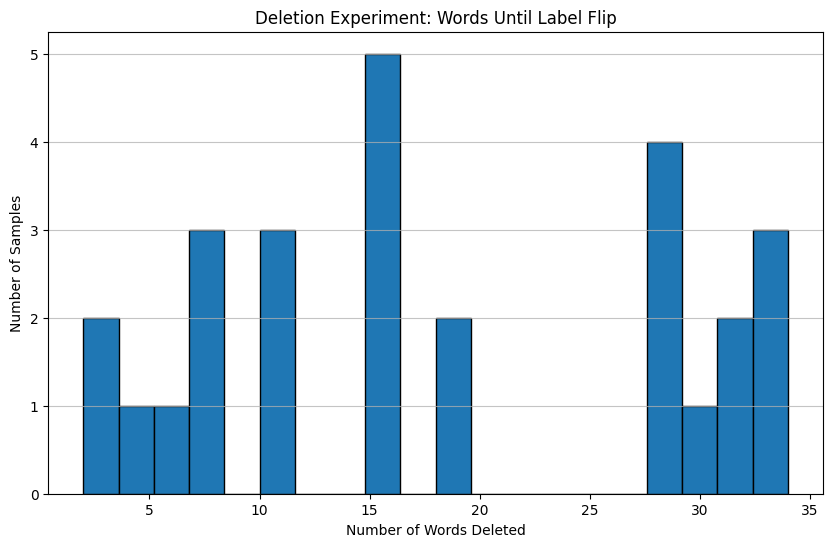

In [29]:
import matplotlib.pyplot as plt

# Extract number of deleted words until flip
num_words_until_flip = df_deletion_results["num_words"]

plt.figure(figsize=(10, 6))
plt.hist(num_words_until_flip, bins=20, edgecolor="black")
plt.title("Deletion Experiment: Words Until Label Flip")
plt.xlabel("Number of Words Deleted")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [30]:
import nltk
from nltk.corpus import wordnet as wn
nltk.download("wordnet")

def get_synonym(word):
    for syn in wn.synsets(word):
        for l in syn.lemmas():
            if l.name().lower() != word.lower():
                return l.name().replace("_", " ")
    return None

def substitution_experiment(shap_values, texts, max_words=40):
    results = []

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]
        words, scores = tokens_to_words(tokens, values)

        # SHAP values for predicted class
        values = shap_values.values[i][:, orig_label]
        tokens = shap_values.data[i]

        words, scores = tokens_to_words(tokens, values)

        # ✅ KEEP ONLY WORDS ALIGNED WITH PREDICTION
        aligned_words = [
            (w, s) for w, s in zip(words, scores) if s > 0
        ]

        # Sort by strongest support
        aligned_words = sorted(
            aligned_words, key=lambda x: x[1], reverse=True
        )

        changed = 0
        for w, _ in aligned_words[:max_words]:
            syn = get_synonym(w)
            if not syn:
                continue
            current_text = current_text.replace(w, syn, 1)
            changed += 1
            new_label, _ = predict_label_and_prob(current_text)
            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": changed,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [34]:
sub_results = substitution_experiment(shap_values, truncated_test_texts)


In [37]:
# Keep only successful flips (ignore None)
sub_results_clean = [r for r in sub_results if r is not None]

df_substitution_results = pd.DataFrame(sub_results_clean)

# Replace numeric labels with readable labels
df_substitution_results["original_label"] = df_substitution_results["original_label"].map({0: "FAKE", 1: "REAL"})
df_substitution_results["new_label"] = df_substitution_results["new_label"].map({0: "FAKE", 1: "REAL"})

df_substitution_results

,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,35,3,said,REAL,FAKE,"the boss is dead but the mafia lives, magistra...","the boss iodines dead but the mafia lives, mag..."


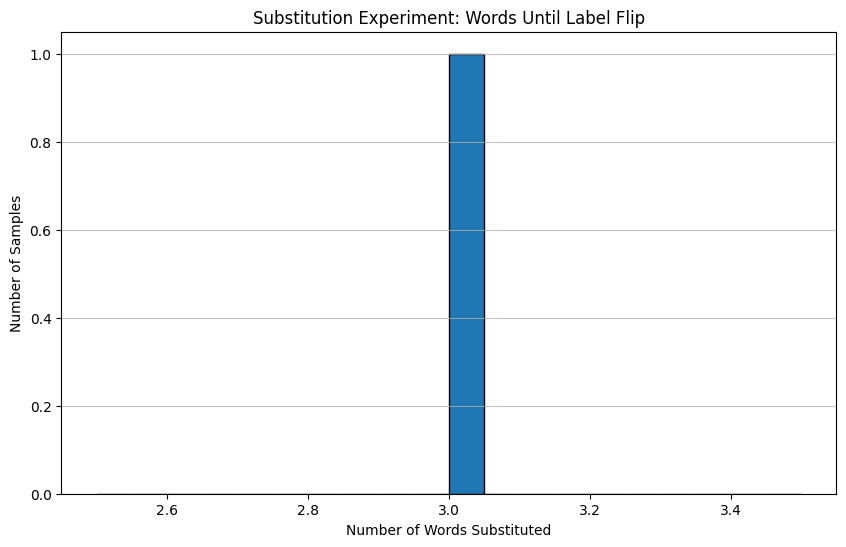

In [38]:
num_words_until_flip = df_substitution_results["num_words"]

plt.figure(figsize=(10, 6))
plt.hist(num_words_until_flip, bins=20, edgecolor="black")
plt.title("Substitution Experiment: Words Until Label Flip")
plt.xlabel("Number of Words Substituted")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [39]:
from collections import defaultdict

def build_global_shap_words(shap_values):
    fake, real = defaultdict(float), defaultdict(float)

    for i in range(len(shap_values.values)):
        tokens = shap_values.data[i]
        vals = shap_values.values[i]
        for t, v in zip(tokens, vals):
            if t.isalpha():
                fake[t.lower()] += v[0]
                real[t.lower()] += v[1]

    return (
        sorted(fake, key=fake.get, reverse=True),
        sorted(real, key=real.get, reverse=True)
    )

fake_words, real_words = build_global_shap_words(shap_values)


In [42]:
fake_words

['tv',
 'fox',
 'z',
 'put',
 'der',
 'spoken',
 'wire',
 'however',
 'oh',
 'ol',
 'berman',
 'pan',
 'all',
 'dem',
 'god',
 'knees',
 'lo',
 'un',
 'real',
 'base',
 'now',
 'mas',
 'w',
 'time',
 'vest',
 'go',
 'film',
 'interview',
 'news',
 'l',
 'matt',
 'jr',
 'days',
 'them',
 'sub',
 'personality',
 'wei',
 'again',
 'damon',
 'er',
 'awhile',
 'democrats',
 'nw',
 'de',
 'ze',
 'zin',
 'models',
 'criminal',
 'greed',
 'in',
 'goal',
 'open',
 'up',
 'wow',
 'why',
 'lawsuit',
 'do',
 'ists',
 'jobs',
 'impossible',
 'pol',
 'just',
 'ffe',
 'contest',
 'under',
 'bell',
 'get',
 'ege',
 'on',
 'aside',
 'chaos',
 'tick',
 'ago',
 'patriot',
 'zone',
 'strong',
 'protest',
 'next',
 'politics',
 'enjoy',
 'living',
 'asked',
 'police',
 'files',
 'su',
 'pp',
 'mis',
 'tal',
 'which',
 'scandal',
 'he',
 'br',
 'sava',
 'nts',
 'you',
 'confident',
 'vulture',
 'nope',
 'riot',
 'science',
 'security',
 'och',
 'fact',
 'evangelist',
 'view',
 'sc',
 'mania',
 'cs',
 'here'

In [43]:
real_words

['tuesday',
 'u',
 'said',
 's',
 'thursday',
 'saturday',
 'law',
 'wednesday',
 'monday',
 'trump',
 'mer',
 'election',
 'an',
 'nty',
 'delegation',
 'residents',
 'jihad',
 'f',
 'iam',
 'turk',
 'nov',
 'statement',
 'da',
 'obama',
 'side',
 'd',
 'friday',
 'scar',
 'are',
 'ex',
 'vi',
 'boycott',
 'ka',
 'ca',
 'lu',
 'nigeria',
 'ku',
 'to',
 'cn',
 'med',
 'kenya',
 'ica',
 'non',
 'critic',
 'fair',
 'care',
 'office',
 'lined',
 'spoke',
 'sw',
 'rev',
 'ass',
 'secure',
 'february',
 'win',
 'week',
 'oo',
 'tanzania',
 'sen',
 'october',
 'region',
 'convention',
 'sal',
 'bu',
 'am',
 'o',
 'tas',
 'aba',
 'country',
 'states',
 'says',
 'reuters',
 'it',
 'reporters',
 'caucus',
 'oct',
 'rights',
 'groups',
 'la',
 'vre',
 'prospect',
 'vo',
 'sic',
 'agency',
 'firing',
 'mu',
 'china',
 'clinton',
 'ma',
 'pri',
 'eb',
 'april',
 'ant',
 'bl',
 'ower',
 'conflict',
 'supporters',
 'k',
 'ra',
 'oy',
 'government',
 'back',
 'co',
 'nos',
 'di',
 'kirk',
 'gut',
 'c

In [48]:
import random

def injection_experiment(texts, fake_words, real_words, max_words=40, seed=42):
    results = []

    random.seed(seed)  # reproducibility

    for i, text in enumerate(texts):
        orig_label, _ = predict_label_and_prob(text)
        current_text = text

        # Choose word pool that pushes toward the opposite class
        word_pool = real_words if orig_label == 0 else fake_words

        changed = 0

        for w in word_pool[:max_words]:
            changed += 1

            # ---- RANDOM POSITION INJECTION ----
            words = current_text.split()
            insert_idx = random.randint(0, len(words))
            words.insert(insert_idx, w)
            current_text = " ".join(words)
            # -----------------------------------

            new_label, _ = predict_label_and_prob(current_text)

            if new_label != orig_label:
                results.append({
                    "num_sample": i,
                    "num_words": changed,
                    "word": w,
                    "original_label": orig_label,
                    "new_label": new_label,
                    "original_text": text,
                    "new_text": current_text
                })
                break
        else:
            results.append(None)

    return results



In [49]:
import pandas as pd

inj_results = injection_experiment(
    truncated_test_texts,
    fake_words,
    real_words
)

inj_results_clean = [r for r in inj_results if r is not None]

df_injection_results = pd.DataFrame(inj_results_clean)

df_injection_results["original_label"] = df_injection_results[
    "original_label"
].map({0: "FAKE", 1: "REAL"})

df_injection_results["new_label"] = df_injection_results[
    "new_label"
].map({0: "FAKE", 1: "REAL"})

df_injection_results


,num_sample,num_words,word,original_label,new_label,original_text,new_text
0,0,18,un,REAL,FAKE,philippines doctor linked to new york attack p...,philippines doctor linked to new york attack p...
1,3,32,jr,REAL,FAKE,those who boycott syrian congress may be sidel...,those who boycott syrian interview congress ma...
2,11,34,them,REAL,FAKE,iraqi forces remove kurdish flag from kirkuk g...,iraqi forces pan remove kurdish flag from kirk...
3,18,40,er,REAL,FAKE,trump : decision on immigrant children coming ...,trump er : days decision on immigrant children...
4,27,11,berman,REAL,FAKE,"nigerian police kill one, arrest two suspects ...","berman nigerian police kill one, arrest two su..."
5,30,15,god,REAL,FAKE,police investigating militants search brussels...,police investigating militants search brussels...
6,35,10,ol,REAL,FAKE,"the boss is dead but the mafia lives, magistra...","the boss is dead but the mafia lives, magistra..."
7,44,34,them,REAL,FAKE,clinton'happy'to join extra debate if other ca...,clinton'happy'to join extra debate if other ca...
8,47,10,ol,REAL,FAKE,beirut activists hold vigil in tribute to murd...,beirut activists hold z vigil in tribute to mu...


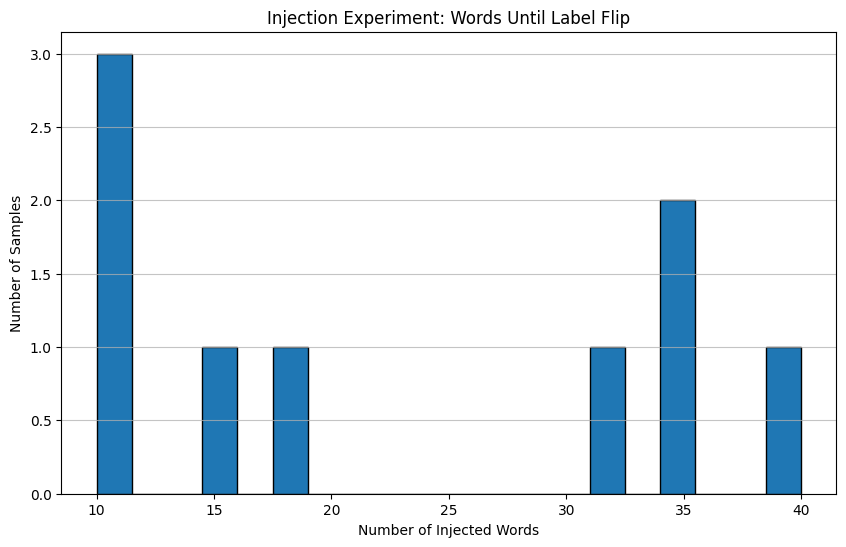

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_injection_results["num_words"], bins=20, edgecolor="black")
plt.title("Injection Experiment: Words Until Label Flip")
plt.xlabel("Number of Injected Words")
plt.ylabel("Number of Samples")
plt.grid(axis="y", alpha=0.75)
plt.show()
